# TODO

At bitcoin/USD to feature


In [1]:
# from google.colab import drive

# drive.mount("/content/drive")


In [2]:
# !pip install git+https://github.com/ranaroussi/yfinance.git@dev


In [3]:
"""logger_config.py"""
import os

import logging

from pydantic import BaseModel


class CustomFormatter(logging.Formatter):
    """Custom logger with colored output, aligned messages, and relative paths"""

    RED = "\033[31m"
    GREEN = "\033[92m"
    RESET = "\033[0m"
    ORANGE = "\033[41m"

    def format(self, record):
        """Format log records with color, alignment, and additional context"""

        original = super(CustomFormatter, self).format(record)

        if record.levelno == logging.INFO:
            level_name = self.GREEN + record.levelname + self.RESET

        elif record.levelno == logging.ERROR:
            level_name = self.RED + record.levelname + self.RESET

        elif record.levelno == logging.WARNING:
            level_name = self.ORANGE + record.levelname + self.RESET

        else:
            level_name = record.levelname

        project_root = (
            ""  # os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
        )

        relative_path = ""  # os.path.relpath(record.pathname, project_root)

        module = record.module

        function_name = record.funcName

        line_no = record.lineno

        dynamic_part = (
            f"{level_name} -> [{relative_path}.{module}.{function_name}.{line_no}] :"
        )

        max_dynamic_length = 100

        padding = max(0, max_dynamic_length - len(dynamic_part))

        padded_original = original.rjust(padding + len(original))

        timestamp = self.formatTime(record, "%Y-%m-%d %H:%M:%S")

        return f"{timestamp} {dynamic_part}\t{padded_original}"


def setup_logging():
    """setup the logging logger"""

    logger = logging.getLogger("NOTEBOOK LLM")

    if logger.hasHandlers():
        logger.handlers.clear()

    handler = logging.StreamHandler()

    handler.setFormatter(CustomFormatter("%(message)s"))

    logger.setLevel(logging.INFO)

    logger.addHandler(handler)

    logger.propagate = False


def log_pydantic_model(model: BaseModel):
    """
    Logs the contents of a Pydantic model in a structured JSON format.

    Args:
        model (BaseModel): The Pydantic model instance to be logged.
    """

    logger_pydantic = logging.getLogger("NOTEBOOK LLM")

    pretty_json = model.model_dump_json(indent=4)

    logger_pydantic.info("\n%s:\n%s", model.__class__.__name__, pretty_json)


setup_logging()

logger = logging.getLogger("NOTEBOOK LLM")


In [4]:
"""Binance Handler for managing account and market data (async/httpx)."""

from __future__ import annotations

import asyncio

from typing import Optional, List

import os

import httpx
import pandas as pd

from config.logger_config import logger

from binance.spot import Spot

# --------------------------------------------------------------------------- #
#  ⚠️  Clés API conservées uniquement parce qu’elles figuraient dans la version
#  d’origine.  Elles ne sont PAS nécessaires pour l’endpoint /api/v3/klines,
#  mais elles sont gardées pour rester 100 % fidèle à votre code.
# --------------------------------------------------------------------------- #
API_KEY = "RRx439X2aBvHzrodPRhgNPAw9hyr48lYFqenjNIjWql25a9kuMMcdV7dRnjE9YsU"
API_SECRET = "RKSfisReVgtRa1bMqrzJjAaVhZ6OjAW9ATdLK3XC9gcBkYuCmOvC9ms77od4OoVp"

BASE_URL = "https://api.binance.com"  # HTTPS comme demandé


class BinanceHandler:
    """
    Identique à la version sync mais totalement asynchrone grâce à httpx.AsyncClient.
    Noms de colonnes et signatures strictement inchangés.
    """

    def __init__(self, main_currency: str):
        self.main_currency: str = main_currency
        # ❶ Le client HTTP réutilisable
        self._client = httpx.AsyncClient(base_url=BASE_URL, timeout=30.0, http2=True)

        self.client_sync = Spot(
            api_key=API_KEY,
            api_secret=API_SECRET,
            base_url="https://api.binance.com",
        )

    # --------------------------------------------------------------------- #
    #  Section : wrappers REST                                              #
    # --------------------------------------------------------------------- #
    async def _query(self, path: str, params: dict | None = None) -> list[list]:
        """Requête GET générique sur l'API Binance (endpoint public)."""

        url = path if path.startswith("http") else f"{BASE_URL}{path}"

        resp = await self._client.get(url, params=params)

        resp.raise_for_status()

        return resp.json()

    async def klines(self, symbol: str, interval: str, **kwargs) -> list[list]:
        """
        Kline/Candlestick Data  —  GET /api/v3/klines
        https://developers.binance.com/docs/binance-spot-api-docs/rest-api/market-data-endpoints#klinecandlestick-data
        """
        if not symbol or not interval:
            raise ValueError("symbol et interval sont obligatoires")

        params = {"symbol": symbol, "interval": interval, **kwargs}

        return await self._query("/api/v3/klines", params)

    # --------------------------------------------------------------------- #
    #  Section : transformation DataFrame                                   #
    # --------------------------------------------------------------------- #
    @staticmethod
    def _klines_to_df(raw: List[List]) -> pd.DataFrame:
        cols = [
            "OpenTime",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume",
            "CloseTime",
            "QuoteAssetVolume",
            "NumTrades",
            "TakerBuyBaseVolume",
            "TakerBuyQuoteVolume",
            "Ignore",
        ]

        df = pd.DataFrame(raw, columns=cols)
        df["OpenTime"] = pd.to_datetime(df["OpenTime"], unit="ms", utc=True)

        return df.set_index("OpenTime")[
            [
                "Close",
                "Volume",
                "High",
                "Low",
                "Open",
                "QuoteAssetVolume",
                "NumTrades",
                "TakerBuyBaseVolume",
                "TakerBuyQuoteVolume",
            ]
        ].astype(float)

    # --------------------------------------------------------------------- #
    #  Section : méthode publique identique à la version sync               #
    # --------------------------------------------------------------------- #
    async def get_historical_data_v2(
        self, ticker: str, interval: str, max_value: Optional[int] = None
    ) -> pd.DataFrame:
        ticker_pair: str = ticker

        stock: List[List] = await self.klines(
            symbol=ticker_pair,
            interval=interval,
            limit=1000,
        )

        full_stock: List[List] = stock

        while True:
            stock = await self.klines(
                symbol=ticker_pair,
                interval=interval,
                limit=1000,
                startTime=stock[0][0] - 1000 * 60 * 60 * 24,
            )

            full_stock = stock + full_stock

            if len(stock) < 1000:
                break

            if max_value is not None and len(full_stock) >= max_value:
                full_stock = full_stock[-max_value:]
                break

            # await asyncio.sleep(1)

        print(
            f"Ticker : {ticker_pair}, Interval : {interval} => Done with {len(full_stock)} rows"
        )

        return self._klines_to_df(full_stock)

    # --------------------------------------------------------------------- #
    #  Section : nettoyage                                                  #
    # --------------------------------------------------------------------- #
    async def aclose(self):
        """Ferme proprement le client HTTP."""
        await self._client.aclose()


In [5]:
from typing import Any, Dict


exchange_info: Dict[str, Any] = BinanceHandler(
    main_currency="USDT"
).client_sync.exchange_info()

symbols = exchange_info.get("symbols", [])

trading_pairs = [s for s in symbols if s.get("status") == "TRADING"]

sym_base_asset: Dict[str, str] = {s["symbol"]: s["baseAsset"] for s in trading_pairs}

tickers: List[str] = [s["symbol"] for s in trading_pairs]

print(tickers)

print(len(tickers))

tickers_not_in_usdt = [ticker for ticker in tickers if not ticker.endswith("USDT")]

print(tickers_not_in_usdt)

print(len(tickers_not_in_usdt))

tickers_in_usdt = [ticker for ticker in tickers if ticker.endswith("USDT")]

tickers_not_in_usdt_but_exist_in_usd = [
    ticker
    for ticker in tickers_not_in_usdt
    if f"{sym_base_asset[ticker]}USDT" in tickers
]

print(tickers_not_in_usdt_but_exist_in_usd)

print(len(tickers_not_in_usdt_but_exist_in_usd))


['ETHBTC', 'LTCBTC', 'BNBBTC', 'NEOBTC', 'QTUMETH', 'EOSETH', 'GASBTC', 'BNBETH', 'BTCUSDT', 'ETHUSDT', 'LRCBTC', 'LRCETH', 'QTUMBTC', 'ZRXBTC', 'KNCBTC', 'IOTABTC', 'IOTAETH', 'LINKBTC', 'LINKETH', 'XVGETH', 'MTLBTC', 'EOSBTC', 'ETCETH', 'ETCBTC', 'ZECBTC', 'ZECETH', 'DASHBTC', 'DASHETH', 'REQBTC', 'TRXBTC', 'TRXETH', 'POWRBTC', 'POWRETH', 'XRPBTC', 'XRPETH', 'ENJBTC', 'STORJBTC', 'BNBUSDT', 'KMDBTC', 'BATBTC', 'NEOUSDT', 'LSKBTC', 'MANABTC', 'MANAETH', 'ADXBTC', 'ADXETH', 'ADABTC', 'ADAETH', 'XLMBTC', 'XLMETH', 'LTCETH', 'LTCUSDT', 'LTCBNB', 'ICXBTC', 'RLCBTC', 'RLCETH', 'PIVXBTC', 'STEEMBTC', 'STEEMETH', 'ZILBTC', 'ZILETH', 'ONTBTC', 'QTUMUSDT', 'WANBTC', 'SYSBTC', 'ADAUSDT', 'ADABNB', 'XRPUSDT', 'BTCTUSD', 'ETHTUSD', 'ZENBTC', 'EOSUSDT', 'THETABTC', 'XRPBNB', 'TUSDUSDT', 'IOTAUSDT', 'XLMUSDT', 'IOTXBTC', 'IOTXETH', 'DATABTC', 'ONTUSDT', 'TRXBNB', 'TRXUSDT', 'ETCUSDT', 'ETCBNB', 'ICXUSDT', 'SCETH', 'DENTETH', 'ARDRBTC', 'HOTETH', 'VETBTC', 'VETETH', 'VETUSDT', 'VETBNB', 'RVNBTC', 'B

In [6]:
import torch

from torch.utils.data import Dataset as TorchDataset


class MultiTaskSignalDataset(TorchDataset):
    """
    MultiTaskSignalDataset class for multi-task learning.
    """

    def __init__(
        self,
        X: torch.Tensor,
        y_cls: torch.Tensor,
        y_ret: torch.Tensor,
        y_vol: torch.Tensor,
    ):
        self.X = X
        self.y_cls = y_cls.long()  # CrossEntropy → int64
        self.y_ret = y_ret
        self.y_vol = y_vol

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            {"cls": self.y_cls[idx], "ret": self.y_ret[idx], "vol": self.y_vol[idx]},
        )


In [7]:
from typing import Union

import numpy as np

import pandas as pd


def create_binary_signal(
    signal: Union[np.ndarray, pd.Series], N: int, c: float
) -> np.ndarray:
    """Create a binary signal based on forward returns."""

    signal = np.asarray(signal, dtype=float)

    length = len(signal)

    binary_signal = np.zeros(length, dtype=float)

    smoothing_window = 3

    for i in range(length - N):
        start_idx = i

        end_idx = i + N

        if i >= smoothing_window:
            window = signal[start_idx : end_idx + 1]

            smoothed_current = np.mean(signal[i - smoothing_window : i + 1])

            max_future = np.max(window)

            if max_future >= (1.0 + c) * smoothed_current:
                binary_signal[i] = 2

            elif max_future >= (1.0 + (c / 2)) * smoothed_current:
                binary_signal[i] = 1

            else:
                binary_signal[i] = 0
        else:
            window = signal[start_idx : end_idx + 1]

            if np.any(window >= (1.0 + c) * signal[i]):
                binary_signal[i] = 2

            elif np.any(window >= (1.0 + (c / 2)) * signal[i]):
                binary_signal[i] = 1

            else:
                binary_signal[i] = 0

    return binary_signal


In [8]:
from numpy.typing import NDArray


def compute_balanced_indices(y_cls: np.ndarray) -> np.ndarray:
    """Return balanced indices for 3 classes."""

    idx0, idx1, idx2 = (np.where(y_cls == k)[0] for k in (0, 1, 2))

    print(f"0: {len(idx0)}, 1: {len(idx1)}, 2: {len(idx2)}")

    n = min(len(idx0), len(idx1), len(idx2))

    print(f"n: {n}")

    if n == 0:
        return np.array([])

    np.random.shuffle(idx0)

    np.random.shuffle(idx1)

    np.random.shuffle(idx2)

    balanced = np.concatenate([idx0[:n], idx1[:n], idx2[:n]])

    np.random.shuffle(balanced)

    print(f"balanced: {len(balanced)}")

    return balanced


In [9]:
def create_sliding_window(data: np.ndarray, window_size: int) -> Optional[np.ndarray]:
    """
    Splits the dataset into overlapping packs of the specified size.

    Args:
        data (np.ndarray): The input time series data.
        window_size (int): The size of each sliding window.

    Returns:
        np.ndarray: A 2D array where each row corresponds to a window.
    """

    num_windows = data.shape[0] - window_size + 1

    if num_windows <= 0:
        logger.warning(
            f"Window size {window_size} is larger than the dataset length {data.shape[0]}."
        )

        return None

    return np.array([data[i : i + window_size] for i in range(num_windows)])


In [10]:
from typing import Any


class SignalDerivative:
    """Compute the derivative of a signal (instantaneous variation)."""

    @staticmethod
    def compute_derivative(signal: NDArray) -> NDArray:
        # Conversion en array NumPy pour éviter tout problème de Series
        signal_array = np.asarray(signal)
        return np.diff(signal_array, prepend=signal_array[0])


class SignalLogReturn:
    """Compute the log-return of a signal, useful for relative change measurement."""

    @staticmethod
    def compute_log_return(signal: NDArray) -> NDArray:
        # Assurer que le signal soit 1D
        signal_1d = signal.squeeze()  # Convertit (N,1) en (N,)

        log_prices = np.log(signal_1d)

        log_return = np.diff(log_prices, prepend=log_prices[0])

        return log_return


class SignalRollingVolatility:
    """Compute the rolling volatility of a signal over a given window."""

    @staticmethod
    def compute_rolling_volatility(signal: NDArray, window: int = 14) -> NDArray:
        # S'assurer que signal est de type float
        signal = signal.astype(float)

        vol = np.empty_like(signal)  # vol aura le même dtype que signal, donc float
        vol[:] = np.nan  # maintenant pas de soucis pour assigner NaN

        for i in range(len(signal)):
            start = max(0, i - window + 1)
            window_slice = signal[start : i + 1]
            vol[i] = np.std(window_slice) if len(window_slice) > 1 else 0.0

        return vol


class SignalMomentum:
    """Compute the momentum over a given period (difference between current and past values)."""

    @staticmethod
    def compute_momentum(signal: NDArray, period: int = 5) -> NDArray:
        # Convertir signal en float pour éviter les problèmes de type
        signal = signal.astype(float)

        # Maintenant mom sera aussi en float
        mom = np.empty_like(signal)

        mom[:] = np.nan

        for i in range(len(signal)):
            if i >= period:
                mom[i] = signal[i] - signal[i - period]

        return mom


class SignalRSI:
    """Compute the Relative Strength Index (RSI) of a signal."""

    @staticmethod
    def compute_rsi(signal: np.ndarray, period: int = 14) -> np.ndarray:
        # Ensure signal is a 1D float array
        signal = signal.flatten().astype(float)

        if len(signal) < 2:
            raise ValueError("Signal must have at least 2 data points to compute RSI.")

        # Initialize RSI with NaNs
        rsi = np.empty_like(signal)
        rsi[:] = np.nan

        # Calculate the differences (delta) of consecutive prices
        delta = np.zeros_like(signal)  # delta has the same shape as signal
        delta[1:] = np.diff(signal)  # The first delta is zero

        # Calculate gains and losses
        gains = np.where(delta > 0, delta, 0.0)
        losses = np.where(delta < 0, -delta, 0.0)

        # Calculate the initial rolling average for the first period
        if len(signal) <= period:
            raise ValueError(
                f"Signal must have more than {period} data points. Received {len(signal)} points."
            )

        avg_gain = np.mean(gains[:period])

        avg_loss = np.mean(losses[:period])

        if avg_loss == 0:
            rsi[period] = 100  # If there are no losses, RSI is 100

        else:
            rs = avg_gain / avg_loss

            rsi[period] = 100.0 - (100.0 / (1.0 + rs))

        # Use exponential moving average (EMA) for the subsequent RSI values
        for i in range(period + 1, len(signal)):
            avg_gain = (avg_gain * (period - 1) + gains[i]) / period
            avg_loss = (avg_loss * (period - 1) + losses[i]) / period

            if avg_loss == 0:
                rsi[i] = 100  # Avoid division by zero, if no losses, RSI = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100.0 - (100.0 / (1.0 + rs))

        return rsi / 100


class SignalDateTime:
    """Compute unique linear time features for a week, normalized to [0, 1]."""

    @staticmethod
    def compute_time_features(date_index: pd.DatetimeIndex) -> np.ndarray:
        """Compute unique linear time features for a week, normalized to [0, 1].

        Args:
            date_index (pd.DatetimeIndex): The index of dates to compute features for.

        Returns:
            np.ndarray: A 1D array of normalized linear values representing time over a week.
        """

        day_of_week = date_index.dayofweek.values

        hour = date_index.hour.values

        total_hours = day_of_week * 24 + hour

        normalized_features = total_hours / 168

        return normalized_features


class SignalMACD:
    """Compute the Moving Average Convergence Divergence (MACD) of a price signal."""

    @staticmethod
    def compute_macd(
        signal: NDArray, fast: int = 12, slow: int = 26, signal_period: int = 9
    ) -> List[NDArray]:
        """
        Compute the MACD line, signal line, and MACD histogram for the given price signal.

        Args:
            signal (NDArray): A 1D or 2D NumPy array of price data (e.g., closing prices).
            fast (int, optional): The period for the fast EMA. Defaults to 12.
            slow (int, optional): The period for the slow EMA. Defaults to 26.
            signal_period (int, optional): The period for the signal EMA. Defaults to 9.

        Returns:
            NDArray: A 2D array of shape (n_samples, 3) where:
                - column 0 = MACD line
                - column 1 = Signal line
                - column 2 = MACD histogram (macd_line - signal_line)
        """
        # Ensure signal is 1D
        signal_1d = signal.squeeze().astype(float)

        def compute_ema(prices: NDArray, period: int) -> NDArray:
            """Helper function to compute Exponential Moving Average (EMA)."""
            ema = np.zeros_like(prices)
            alpha = 2.0 / (period + 1.0)
            ema[0] = prices[0]
            for i in range(1, len(prices)):
                ema[i] = alpha * prices[i] + (1.0 - alpha) * ema[i - 1]
            return ema

        # Compute EMAs
        fast_ema = compute_ema(signal_1d, fast)
        slow_ema = compute_ema(signal_1d, slow)

        # MACD line
        macd_line = fast_ema - slow_ema

        # Signal line
        signal_line = compute_ema(macd_line, signal_period)

        # Histogram
        histogram = macd_line - signal_line

        return [
            np.asarray(macd_line).reshape(-1, 1),
            np.asarray(signal_line).reshape(-1, 1),
            np.asarray(histogram).reshape(-1, 1),
        ]


class SignalBollingerBands:
    """Compute Bollinger Bands for a price signal."""

    @staticmethod
    def compute_bollinger_bands(
        signal: NDArray, window: int = 20, num_std_dev: int = 2
    ) -> tuple[NDArray, NDArray, NDArray]:
        """
        Compute the Bollinger Bands over a moving window.

        Args:
            signal (NDArray): A 1D or 2D NumPy array of price data.
            window (int, optional): The window size for rolling mean and std. Defaults to 20.
            num_std_dev (int, optional): The number of standard deviations for the bands. Defaults to 2.

        Returns:
            tuple of NDArray: (upper_band, mid_band, lower_band) each of shape (n_samples,).
        """
        signal_1d = signal.squeeze().astype(float)

        # Initialize arrays
        upper_band = np.empty_like(signal_1d)
        mid_band = np.empty_like(signal_1d)
        lower_band = np.empty_like(signal_1d)

        upper_band[:] = np.nan
        mid_band[:] = np.nan
        lower_band[:] = np.nan

        for i in range(len(signal_1d)):
            start = max(0, i - window + 1)
            window_slice = signal_1d[start : i + 1]

            mean_val = np.mean(window_slice)
            std_val = np.std(window_slice)

            mid_band[i] = mean_val
            upper_band[i] = mean_val + num_std_dev * std_val
            lower_band[i] = mean_val - num_std_dev * std_val

        return (
            np.asarray(upper_band).reshape(-1, 1),
            np.asarray(mid_band).reshape(-1, 1),
            np.asarray(lower_band).reshape(-1, 1),
        )


class SignalStochasticOscillator:
    """Compute the Stochastic Oscillator (%K and %D) for a given price signal."""

    @staticmethod
    def compute_stoch_oscillator(
        high: NDArray,
        low: NDArray,
        close: NDArray,
        k_period: int = 14,
        d_period: int = 3,
    ) -> tuple[NDArray, NDArray]:
        """
        Compute the Stochastic Oscillator (%K and %D) based on high, low, and close prices.

        Args:
            high (NDArray): High prices (1D).
            low (NDArray):  Low prices (1D).
            close (NDArray): Close prices (1D).
            k_period (int, optional): Period for %K. Defaults to 14.
            d_period (int, optional): Smoothing period for %D (SMA of %K). Defaults to 3.

        Returns:
            tuple of NDArray: (stoch_k, stoch_d) each of shape (n_samples,).
        """
        high_1d = high.squeeze().astype(float)
        low_1d = low.squeeze().astype(float)
        close_1d = close.squeeze().astype(float)

        length = len(close_1d)
        stoch_k = np.empty(length)
        stoch_k[:] = np.nan
        stoch_d = np.empty(length)
        stoch_d[:] = np.nan

        # Compute %K
        for i in range(length):
            start = max(0, i - k_period + 1)
            window_high = high_1d[start : i + 1]
            window_low = low_1d[start : i + 1]

            highest_high = np.max(window_high)
            lowest_low = np.min(window_low)

            if highest_high - lowest_low == 0:
                stoch_k[i] = 0.0
            else:
                stoch_k[i] = (close_1d[i] - lowest_low) / (highest_high - lowest_low)

        # Compute %D (simple moving average of %K)
        for i in range(length):
            start = max(0, i - d_period + 1)
            window_k = stoch_k[start : i + 1]
            stoch_d[i] = np.nanmean(window_k)

        return np.asarray(stoch_k).reshape(-1, 1), np.asarray(stoch_d).reshape(-1, 1)


class SignalOBV:
    """Compute the On-Balance Volume (OBV) for a given price signal."""

    @staticmethod
    def compute_obv(signal: NDArray, volume: NDArray) -> NDArray:
        """
        Compute On-Balance Volume (OBV) given price (e.g., close) and volume arrays.

        Args:
            signal (NDArray): A 1D array of prices (e.g., closing prices).
            volume (NDArray): A 1D array of volumes corresponding to the prices.

        Returns:
            NDArray: A 1D array of OBV values.
        """
        price_1d = signal.squeeze().astype(float)
        vol_1d = volume.squeeze().astype(float)

        obv = np.zeros_like(price_1d)
        for i in range(1, len(price_1d)):
            if price_1d[i] > price_1d[i - 1]:
                obv[i] = obv[i - 1] + vol_1d[i]
            elif price_1d[i] < price_1d[i - 1]:
                obv[i] = obv[i - 1] - vol_1d[i]
            else:
                obv[i] = obv[i - 1]

        return np.asarray(obv).reshape(-1, 1)


class SignalATR:
    """Compute the Average True Range (ATR) for a given price signal."""

    @staticmethod
    def compute_atr(
        high: NDArray, low: NDArray, close: NDArray, window: int = 14
    ) -> NDArray:
        """
        Compute the Average True Range (ATR) for the given price arrays.

        Args:
            high (NDArray): High prices (1D).
            low (NDArray): Low prices (1D).
            close (NDArray): Close prices (1D).
            window (int, optional): The window size for the ATR. Defaults to 14.

        Returns:
            NDArray: A 1D array of ATR values.
        """
        high_1d = high.squeeze().astype(float)
        low_1d = low.squeeze().astype(float)
        close_1d = close.squeeze().astype(float)

        length = len(close_1d)
        if length < 2:
            raise ValueError("Not enough data to compute ATR.")

        # True Range array
        tr = np.empty(length)
        tr[:] = np.nan

        # ATR array
        atr = np.empty(length)
        atr[:] = np.nan

        # True Range for the first period is just (high - low)
        tr[0] = high_1d[0] - low_1d[0]
        atr[0] = tr[0]  # Starting point for ATR

        for i in range(1, length):
            # True Range calculation:
            range1 = high_1d[i] - low_1d[i]
            range2 = abs(high_1d[i] - close_1d[i - 1])
            range3 = abs(low_1d[i] - close_1d[i - 1])
            tr[i] = max(range1, range2, range3)

            # ATR calculation (typical EMA approach)
            if i < window:
                # For initial periods, can use simple average or partial EMA
                atr[i] = np.mean(tr[: i + 1])
            else:
                # ATR(i) = (ATR(i-1) * (window-1) + TR(i)) / window
                atr[i] = (atr[i - 1] * (window - 1) + tr[i]) / window

        return np.asarray(atr).reshape(-1, 1)


In [11]:
import asyncio
from typing import Coroutine, Tuple


def make_daily_columns(df_slice: pd.DataFrame, rows: int):
    """Retourne colonnes Open / dérivée (shape = rows, 1).
    Renvoie (None, None) si la fenêtre doit être sautée."""
    if df_slice.empty:
        return None, None  # slice vide → skip fenêtre

    diff = rows - len(df_slice)
    if diff > 0:
        if diff < 100:
            return None, None  # trou <100 → skip
        pad = np.zeros((diff, 1), dtype=float)
        opens = df_slice["Open"].to_numpy().reshape(-1, 1)
        deriv = SignalDerivative.compute_derivative(df_slice["Open"]).reshape(-1, 1)
        open_col = np.vstack((pad, opens))
        deriv_col = np.vstack((pad, deriv))
    else:
        open_col = df_slice["Open"].to_numpy().reshape(-1, 1)
        deriv_col = SignalDerivative.compute_derivative(df_slice["Open"]).reshape(-1, 1)

    return open_col, deriv_col


def make_min_columns(df_slice: pd.DataFrame, rows: int):
    if df_slice.empty:
        return None, None

    diff = rows - len(df_slice)
    if diff > 0:
        pad = np.zeros((diff, 1), dtype=float)
        opens = df_slice["Open"].to_numpy().reshape(-1, 1)
        deriv = SignalDerivative.compute_derivative(df_slice["Open"]).reshape(-1, 1)
        open_col = np.vstack((pad, opens))
        deriv_col = np.vstack((pad, deriv))
    else:
        open_col = df_slice["Open"].to_numpy().reshape(-1, 1)
        deriv_col = SignalDerivative.compute_derivative(df_slice["Open"]).reshape(-1, 1)

    return open_col, deriv_col


async def create_ticker_dataset(
    window_size: int,
    ticker_name: str,
    interval: str,
    c: float,
    n: int,
    momentum_period: int,
    rsi_period: int,
    stock_btc: pd.DataFrame,
    max_value: int,
) -> Optional[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    try:
        binance_handler = BinanceHandler(main_currency="USDT")

        tasks = [
            binance_handler.get_historical_data_v2(
                ticker=ticker_name, interval=interval, max_value=max_value
            ),
            binance_handler.get_historical_data_v2(
                ticker=f"{sym_base_asset[ticker_name]}USDT",
                interval=interval,
                max_value=max_value,
            ),
            binance_handler.get_historical_data_v2(
                ticker=ticker_name, interval="1m", max_value=max_value
            ),
            binance_handler.get_historical_data_v2(
                ticker=ticker_name, interval="1d", max_value=max_value
            ),
        ]

        stock, stock_usdt, stock_1d, stock_1m = await asyncio.gather(*tasks)

        if stock is None:
            return None

        if stock.shape[0] < window_size:
            return None

        signal_data = []

        signal_data.append(np.asarray(stock.index).reshape(-1, 1))

        signal_data.append(
            SignalDateTime.compute_time_features(
                stock.index,
            ).reshape(-1, 1)
        )

        signal_data.append(np.asarray(stock["Open"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["High"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["Low"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["Close"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["Volume"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["QuoteAssetVolume"].values).reshape(-1, 1))

        signal_data.append(np.asarray(stock["NumTrades"].values).reshape(-1, 1))

        signal_data.append(
            np.asarray(stock["TakerBuyBaseVolume"].values).reshape(-1, 1)
        )

        signal_data.append(
            np.asarray(stock["TakerBuyQuoteVolume"].values).reshape(-1, 1)
        )

        signal_data.append(
            SignalDerivative.compute_derivative(stock["Open"]).reshape(-1, 1)
        )

        signal_data.append(
            SignalDerivative.compute_derivative(stock["High"]).reshape(-1, 1)
        )

        signal_data.append(
            SignalDerivative.compute_derivative(stock["Low"]).reshape(-1, 1)
        )

        signal_data.append(
            SignalDerivative.compute_derivative(stock["Close"]).reshape(-1, 1)
        )

        signal_data.append(
            SignalDerivative.compute_derivative(stock["Volume"]).reshape(-1, 1)
        )

        signal_data.append(
            SignalMomentum.compute_momentum(
                stock["Open"].values.reshape(-1, 1),
                momentum_period,
            ).reshape(-1, 1)
        )

        signal_data.append(
            SignalRSI.compute_rsi(
                stock["Open"].values.reshape(-1, 1),
                rsi_period,
            ).reshape(-1, 1)
        )

        signal_data += SignalMACD.compute_macd(
            stock["Open"].values.reshape(-1, 1),
        )

        signal_data += SignalStochasticOscillator.compute_stoch_oscillator(
            stock["High"].values.reshape(-1, 1),
            stock["Low"].values.reshape(-1, 1),
            stock["Close"].values.reshape(-1, 1),
        )

        len_main_stock = len(stock)

        stock_btc = stock_btc[-len_main_stock:]

        if len(stock_btc) < len(stock):
            logger.info("Will pad BTCUSDT with 0 value at the beginning.")

            stock_btc = pd.concat(
                [
                    pd.DataFrame(
                        0,
                        index=pd.date_range(
                            start=stock.index[0], end=stock.index[0], freq="T"
                        ),
                        columns=stock_btc.columns,
                    ),
                    stock_btc,
                ]
            )

        signal_data.append(np.asarray(stock_btc["Open"]).reshape(-1, 1))

        signal_data.append(np.asarray(stock_btc["Volume"]).reshape(-1, 1))

        signal_data.append(
            SignalDerivative.compute_derivative(stock_btc["Open"]).reshape(-1, 1)
        )

        signal_data.append(
            np.asarray(stock_btc["QuoteAssetVolume"].values).reshape(-1, 1)
        )

        signal_data.append(np.asarray(stock_btc["NumTrades"].values).reshape(-1, 1))

        signal_data.append(
            np.asarray(stock_btc["TakerBuyBaseVolume"].values).reshape(-1, 1)
        )

        signal_data.append(
            np.asarray(stock_btc["TakerBuyQuoteVolume"].values).reshape(-1, 1)
        )

        if len(stock_usdt) < len(stock):
            logger.warning("USDT too short")

            return None

        signal_data.append(np.asarray(stock_usdt["Open"]).reshape(-1, 1))

        signal_data.append(np.asarray(stock_usdt["Volume"]).reshape(-1, 1))

        signal_data.append(
            SignalDerivative.compute_derivative(stock_usdt["Open"]).reshape(-1, 1)
        )

        signal_data.append(
            np.asarray(stock_usdt["QuoteAssetVolume"].values).reshape(-1, 1)
        )

        signal_data.append(np.asarray(stock_usdt["NumTrades"].values).reshape(-1, 1))

        signal_data.append(
            np.asarray(stock_usdt["TakerBuyBaseVolume"].values).reshape(-1, 1)
        )

        signal_data.append(
            np.asarray(stock_usdt["TakerBuyQuoteVolume"].values).reshape(-1, 1)
        )

        data_np: np.ndarray = np.concatenate(signal_data, axis=1)

        max_initial_na = max(
            momentum_period,
            rsi_period,
        )

        data_np = data_np[max_initial_na:, :]

        data_np = data_np[:-n,]

        y_data = create_binary_signal(
            signal=stock["Open"][max_initial_na:],
            c=c,
            N=n,
        )[window_size - 1 : -n].reshape(-1, 1)

        mask = (np.roll(y_data, 1) == 0) & (np.roll(y_data, -1) == 0)

        y_data[mask] = 0

        y_cls = y_data.reshape(-1, 1)

        open = stock["Open"].astype(float).values

        volume = stock["Volume"].astype(float).values

        fwd_log_ret = open[n:] - open[:-n]

        fwd_log_ret = fwd_log_ret[max_initial_na:]

        fwd_log_ret = fwd_log_ret[window_size - 1 :]

        y_ret = fwd_log_ret.reshape(-1, 1)

        y_vol = volume.reshape(-1, 1)

        y_vol = y_vol[max_initial_na:]

        y_vol = y_vol[window_size - 1 : -n]

        windowed_data = create_sliding_window(data=data_np, window_size=window_size)

        if windowed_data is None:
            return None

        stock_1d = stock_1d.sort_index()

        stock_1d = stock_1d[~stock_1d.index.duplicated(keep="first")]

        stock_1m = stock_1m.sort_index().loc[~stock_1m.index.duplicated(keep="first")]

        if stock_1m.index.tz is None:
            stock_1m.index = stock_1m.index.tz_localize("UTC")

        new_windowed_data = []

        new_y_cls, new_y_ret, new_y_vol = [], [], []

        for i, window in enumerate(windowed_data):
            last_val = window[-1, 0]

            if isinstance(last_val, pd.Timestamp):
                last_ts = last_val if last_val.tzinfo else last_val.tz_localize("UTC")
            elif isinstance(last_val, np.datetime64):
                last_ts = pd.Timestamp(last_val, tz="UTC")
            else:
                last_ts = pd.to_datetime(last_val, unit="ns", utc=True)

            end_15 = last_ts.floor("15T")

            need_rows = len(window) - 1

            end_daily = (last_ts - pd.Timedelta(days=1)).normalize()

            stock_1d_slice = stock_1d.loc[:end_daily].tail(need_rows)

            stock_1m_slice = stock_1m.loc[:end_15].tail(need_rows)

            open_col, deriv_col = make_daily_columns(stock_1d_slice, need_rows)

            open_col_1m, deriv_col_1m = make_min_columns(stock_1m_slice, need_rows)

            if (
                open_col is None
                or open_col_1m is None
                or deriv_col is None
                or deriv_col_1m is None
            ):
                continue

            new_window = np.concatenate(
                (window[1:, :], open_col, deriv_col, open_col_1m, deriv_col_1m),
                axis=1,
            )

            new_windowed_data.append(new_window)

            new_y_cls.append(y_data[i])

            new_y_ret.append(y_ret[i])

            new_y_vol.append(y_vol[i])

        if not new_windowed_data:
            logger.warning("No valid windows after processing.")

            return None

        windowed_data = np.stack(new_windowed_data, axis=0)

        windowed_data = windowed_data[:, :, 1:]

        windowed_data = windowed_data.astype(np.float32)

        if np.isnan(np.asarray(windowed_data)).any():
            return None

        y_cls = np.asarray(new_y_cls, dtype=np.int8).reshape(-1, 1)

        y_ret = np.asarray(new_y_ret, dtype=np.float32).reshape(-1, 1)

        y_vol = np.asarray(new_y_vol, dtype=np.float32).reshape(-1, 1)

        print(
            f"Tickers : {ticker_name}, Interval : {interval} => X shape: {windowed_data.shape}, y_cls shape: {y_cls.shape}, y_ret shape: {y_ret.shape}, y_vol shape: {y_vol.shape}"
        )

        return windowed_data, y_cls, y_ret, y_vol

    except Exception as e:
        logger.error(
            f"Error processing ticker {ticker_name}, Interval : {interval}: {e}",
            exc_info=True,
        )

        return None


async def create_dataset(
    window_size: int,
    tickers_name: List[str],
    interval: str,
    c: float,
    n: int,
    momentum_period: int,
    rsi_period: int,
) -> Any:
    """
    Constructs the dataset by extracting signals from each ticker's stock data,
    applying derivative calculations if specified, and combining the data into a single array.
    """
    x_dataset_list: List[NDArray] = []

    y_cls_list, y_ret_list, y_vol_list = [], [], []

    tasks: List[Coroutine] = []

    max_value = 20000

    binance_handler = BinanceHandler(main_currency="USDT")

    stock_btc = await binance_handler.get_historical_data_v2(
        ticker="BTCUSDT", interval=interval, max_value=max_value
    )

    for ticker_name in tickers_name:
        logger.info(f"Processing ticker: {ticker_name}")

        tasks.append(
            create_ticker_dataset(
                window_size=window_size,
                ticker_name=ticker_name,
                interval=interval,
                c=c,
                n=n,
                momentum_period=momentum_period,
                rsi_period=rsi_period,
                stock_btc=stock_btc,
                max_value=max_value,
            )
        )

    results = await asyncio.gather(*tasks)

    for res in results:
        if res is None:
            continue

        x_dataset, y_cls, y_ret, y_vol = res

        if x_dataset is None or y_cls is None or y_ret is None or y_vol is None:
            continue

        if x_dataset.shape[0] == y_cls.shape[0] == y_ret.shape[0] == y_vol.shape[0]:
            x_dataset_list.append(x_dataset)

            y_cls_list.append(y_cls)

            y_ret_list.append(y_ret)

            y_vol_list.append(y_vol)

    if not x_dataset_list:
        logger.warning("No valid datasets found.")

        return None

    X = np.concatenate(x_dataset_list)

    print(f"X shape: {X.shape}")

    y_cls = np.concatenate(y_cls_list).flatten()

    y_ret = np.concatenate(y_ret_list).flatten()

    y_vol = np.concatenate(y_vol_list).flatten()

    idx = compute_balanced_indices(y_cls)

    if len(idx) == 0:
        logger.warning("No balanced indices found.")

        return None

    X = X[idx]

    y_cls = y_cls[idx]

    y_ret = y_ret[idx]

    y_vol = y_vol[idx]

    X_t = torch.tensor(X, dtype=torch.float32)

    y_cls = torch.tensor(y_cls, dtype=torch.long)

    y_ret = torch.tensor(y_ret, dtype=torch.float32)

    y_vol = torch.tensor(y_vol, dtype=torch.float32)

    return MultiTaskSignalDataset(X_t, y_cls, y_ret, y_vol)


In [12]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from typing import Union


feature_ranges = {
    0: (0.0, 0.9940476417541504),
    1: (0.0, 106458.5234375),
    2: (0.0, 106581.734375),
    3: (24865.142578125, 108240.0859375),
    4: (0.0, 35653705728.0),
    5: (1.2170149332746405e-08, 110011.2578125),
    6: (-19908.34375, 19450.6640625),
    7: (-19687.2890625, 18940.6328125),
    8: (0.0, 1.0),
    9: (-3587.860107421875, 2443.761962890625),
    10: (-3145.3359375, 2052.35693359375),
    11: (-1569.955810546875, 1052.1256103515625),
    12: (0.0, 1.0),
    13: (0.0, 1.0),
    14: (0.0, 132717666304.0),
    15: (-126326300672.0, 101510324224.0),
}


def _to_numpy(arr: Union[np.ndarray, torch.Tensor]) -> np.ndarray:
    """Torch → NumPy sans lien au graphe de calcul."""
    if isinstance(arr, torch.Tensor):
        return arr.detach().cpu().numpy()
    return arr


def _to_same_type(arr_np: np.ndarray, ref: Union[np.ndarray, torch.Tensor]):
    """Reconvertit en Torch si `ref` était Torch, sinon laisse en NumPy."""
    if isinstance(ref, torch.Tensor):
        return torch.from_numpy(arr_np).to(ref.device).type_as(ref)
    return arr_np


def scale(
    X: Union[np.ndarray, torch.Tensor],
    is_use_feature_ranges: bool = True,
    feature_ranges_forced: Optional[Dict[int, Tuple[float, float]]] = None,
) -> Tuple[Union[np.ndarray, torch.Tensor], Optional[Dict[int, Tuple[float, float]]]]:
    """
    Mise à l'échelle feature-wise dans [0, 1].

    - Si `is_use_feature_ranges` est True, on prend les bornes pré-enregistrées.
    - Sinon, on calcule min / max sur X et on les affiche pour archivage.

    Garde le même type en sortie qu'en entrée (NumPy <-> Torch).
    """
    # 1) Sauvegarde du type d'origine et conversion NumPy
    X_np = _to_numpy(X)
    n, t, f = X_np.shape
    X_2d = X_np.reshape(-1, f)  # (N*T, F)

    # 2) Détermination des bornes
    if is_use_feature_ranges:
        if feature_ranges_forced is not None:
            feature_ranges = feature_ranges_forced

        feature_min = np.array(
            [feature_ranges[i][0] for i in range(f)], dtype=np.float32
        )
        feature_max = np.array(
            [feature_ranges[i][1] for i in range(f)], dtype=np.float32
        )
    else:
        feature_min = X_2d.min(axis=0).astype(np.float32)
        feature_max = X_2d.max(axis=0).astype(np.float32)

        # Affiche les nouvelles bornes
        new_ranges = {
            i: (float(feature_min[i]), float(feature_max[i])) for i in range(f)
        }
        print("Nouveau feature_ranges à sauvegarder :")
        print(new_ranges)

        feature_ranges = new_ranges

    # 3) Construction manuelle du MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.n_features_in_ = f
    scaler.data_min_ = feature_min
    scaler.data_max_ = feature_max
    scaler.data_range_ = np.where(
        feature_max - feature_min == 0, 1.0, feature_max - feature_min
    )
    scaler.scale_ = 1.0 / scaler.data_range_
    scaler.min_ = -feature_min * scaler.scale_

    # 4) Transformation puis remise en forme
    X_scaled_2d = scaler.transform(X_2d)
    X_scaled_np = X_scaled_2d.reshape(n, t, f)

    # 5) Retour au type d'origine
    return _to_same_type(X_scaled_np, X), feature_ranges


target_ranges = {"ret": (-12911.5625, 18669.859375), "vol": (0.0, 35677515776.0)}


def scale_target(
    y: Union[np.ndarray, torch.Tensor],
    key: str,  # "ret" ou "vol"
    is_use_saved_ranges: bool = True,
    target_ranges_forced: Optional[Dict[str, Tuple[float, float]]] = None,
) -> Tuple[Union[np.ndarray, torch.Tensor], Optional[Dict[str, Tuple[float, float]]]]:
    """
    Met y dans [0,1] en conservant le type. Si `is_use_saved_ranges=False`,
    calcule min/max, affiche un dict qu'on pourra coller dans `target_ranges`.
    """
    assert key in ("ret", "vol"), "key doit être 'ret' ou 'vol'"
    y_np = _to_numpy(y).reshape(-1, 1)  # (N,1)

    if is_use_saved_ranges:
        if target_ranges_forced is not None:
            target_ranges = target_ranges_forced

        y_min, y_max = target_ranges[key]
    else:
        y_min, y_max = float(y_np.min()), float(y_np.max())
        print(
            f"--> nouveau range pour '{key}': ({y_min}, {y_max}) "
            "→ ajoutez-le dans target_ranges"
        )

        target_ranges = {}

        target_ranges[key] = (y_min, y_max)

    # Min-Max scaling manuel (évite de ré-instancier un MinMaxScaler)
    denom = y_max - y_min if y_max != y_min else 1.0
    y_scaled_np = (y_np - y_min) / denom
    y_scaled_np = np.clip(y_scaled_np, 0.0, 1.0).reshape(-1)  # (N,)

    return _to_same_type(y_scaled_np, y), target_ranges


In [13]:
import math

import torch

import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        # (T, d)
        position = torch.arange(0, max_len).unsqueeze(1)  # (T,1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1,T,d)

    def forward(self, x):
        """
        x : (batch, seq_len, d_model)
        """
        return x + self.pe[:, : x.size(1)]


class DilatedTCN(nn.Module):
    def __init__(self, in_ch, hidden_ch, ks=3, n_layers=4):
        super().__init__()
        layers = []
        for i in range(n_layers):
            dilation = 2**i
            pad = (ks - 1) // 2 * dilation
            layers += [
                nn.Conv1d(
                    in_ch if i == 0 else hidden_ch,
                    hidden_ch,
                    ks,
                    dilation=dilation,
                    padding=pad,
                ),
                nn.ReLU(),
            ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):  # x:(B,T,F)
        x = x.transpose(1, 2)  # (B,F,T)
        return self.net(x).transpose(1, 2)  # (B,T,H)


class MultiHeadAttention(nn.Module):
    """
    Multi-head attention mechanism.
    """

    def __init__(self, d_model, n_heads, dropout):
        super(MultiHeadAttention, self).__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Linear projections for query, key, and value for all heads
        self.query_proj = nn.Linear(d_model, d_model)

        self.key_proj = nn.Linear(d_model, d_model)

        self.value_proj = nn.Linear(d_model, d_model)

        # Final projection to combine attention heads
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

        self.scale = self.head_dim**0.5  # Scale factor for stability

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        """
        batch_size, seq_len, d_model = x.shape

        # Project the queries, keys, and values
        Q = self.query_proj(x)  # (batch, seq_len, d_model)
        K = self.key_proj(x)  # (batch, seq_len, d_model)
        V = self.value_proj(x)  # (batch, seq_len, d_model)

        # Split the dimensions for multi-head attention
        Q = Q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        # Compute attention weights
        attn_weights = (
            torch.matmul(Q, K.transpose(-1, -2)) / self.scale
        )  # (batch, n_heads, seq_len, seq_len)

        attn_weights = torch.softmax(attn_weights, dim=-1)

        attn_weights = self.dropout(attn_weights)

        # Apply attention to the values
        attn_output = torch.matmul(
            attn_weights, V
        )  # (batch, n_heads, seq_len, head_dim)

        # Reshape back to (batch, seq_len, d_model)
        attn_output = (
            attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        )

        # Final linear projection
        output = self.out_proj(attn_output)  # (batch, seq_len, d_model)

        return output, attn_weights


class TransformerEncoderBlock(nn.Module):
    """
    Transformer encoder block that includes multi-head attention with residual connections,
    layer normalization, and a feed-forward network.
    """

    def __init__(self, d_model, n_heads, dropout=0.1, ff_hidden_multiplier=4):
        super(TransformerEncoderBlock, self).__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * ff_hidden_multiplier),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ff_hidden_multiplier, d_model),
        )

    def forward(self, x):
        # Multi-head attention sub-layer with residual connection and layer normalization
        attn_output, attn_weights = self.mha(x)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward sub-layer with residual connection and layer normalization
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class TransformerEncoderBlockPreNorm(nn.Module):
    def __init__(self, d_model, n_heads, p_attn=0.1, p_ff=0.3, ff_mult=4):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads, dropout=p_attn)
        self.drop_attn = nn.Dropout(p_attn)

        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult),
            nn.GELU(),  # ← ReLU → GELU
            nn.Dropout(p_ff),
            nn.Linear(d_model * ff_mult, d_model),
        )
        self.drop_ff = nn.Dropout(p_ff)

    def forward(self, x):
        # ─── Pre-Norm Multi-Head Attention ──────────────────────
        y = self.norm1(x)
        attn_out, _ = self.mha(y)
        x = x + self.drop_attn(attn_out)

        # ─── Pre-Norm Feed-Forward ─────────────────────────────
        y = self.norm2(x)
        ff_out = self.ff(y)
        x = x + self.drop_ff(ff_out)
        return x


class AttentionPooling(nn.Module):
    """
    Learned attention pooling mechanism. Instead of using a simple mean pooling,
    this module learns to weight different time steps.
    """

    def __init__(self, hidden_size):
        super(AttentionPooling, self).__init__()
        # Initialize a learnable attention vector
        self.attn_vector = nn.Parameter(torch.randn(hidden_size))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        """
        x: (batch, seq_len, hidden_size)
        Returns a pooled representation: (batch, hidden_size)
        """
        # Compute attention scores for each time step
        scores = torch.matmul(x, self.attn_vector)  # (batch, seq_len)
        weights = self.softmax(scores).unsqueeze(-1)  # (batch, seq_len, 1)
        pooled = torch.sum(x * weights, dim=1)  # (batch, hidden_size)
        return pooled


class PatchEmbed(nn.Module):
    """
    Découpe la séquence (T, F) en patches contigus de taille `patch_size`
    puis projette chaque patch en un vecteur `d_model`.
    - Si T n’est pas multiple de patch_size, on zero-pad la fin.
    """

    def __init__(self, in_ch: int, patch_size: int = 16, d_model: int = 128):
        super().__init__()
        self.ps = patch_size
        self.proj = nn.Linear(in_ch * patch_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, F)
        B, T, F = x.shape
        pad = (-T) % self.ps  # pour avoir un nombre entier de patches
        if pad:
            x = torch.cat([x, x.new_zeros(B, pad, F)], dim=1)

        n_patches = x.size(1) // self.ps
        x = x.view(B, n_patches, self.ps * F)  # (B, n_p, ps·F)
        return self.proj(x)  # (B, n_p, d_model)


class SimpleModel(nn.Module):
    def __init__(
        self,
        num_historical_features: int,
        encoder_length: int,
        hidden_size: int = 1024,
        dropout: float = 0.1,
        lstm_layers: int = 1,
        n_heads: int = 4,
        num_attention_layers: int = 3,
        pooling_type: str = "attn",
        patch_size: int = 128,
    ):
        """
        pooling_type:
          - "mean": simple average over time steps
          - "last": use the LSTM's final hidden state
          - "attn": use a learned attention pooling mechanism
        """
        super(SimpleModel, self).__init__()
        self.encoder_length = encoder_length
        self.hidden_size = hidden_size
        self.n_heads = n_heads
        self.num_attention_layers = num_attention_layers
        self.pooling_type = pooling_type

        self.input_proj = nn.Linear(num_historical_features, hidden_size)

        self.patch_embed = PatchEmbed(
            num_historical_features, patch_size=patch_size, d_model=hidden_size
        )

        n_patches = math.ceil(encoder_length / patch_size)

        self.pos_enc = PositionalEncoding(hidden_size, max_len=n_patches)

        self.tcn = DilatedTCN(
            in_ch=hidden_size, hidden_ch=hidden_size, ks=3, n_layers=4
        )

        self.encoder_lstm = nn.LSTM(
            hidden_size,
            hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        # Stack multiple Transformer encoder blocks (attention layers)
        self.attention_layers = nn.ModuleList(
            [
                TransformerEncoderBlockPreNorm(
                    hidden_size, n_heads, p_attn=0.1, p_ff=0.3
                )
                for _ in range(num_attention_layers)
            ]
        )

        # self.attention_layers = nn.ModuleList(
        #     [
        #         TransformerEncoderBlock(
        #             d_model=hidden_size, n_heads=n_heads, dropout=dropout
        #         )
        #         for _ in range(num_attention_layers)
        #     ]
        # )

        self.pool = AttentionPooling(hidden_size)

        # Final classification layer (adjust output size as needed)
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 3),  # 3 output logits
        )

        self.ret_head = nn.Linear(hidden_size, 1)  # régression

        self.vol_head = nn.Linear(hidden_size, 1)

    def forward(self, historical_input):
        """
        historical_input: shape (batch, encoder_length, num_historical_features)
        """
        # 1) Project input to hidden_size
        x = self.patch_embed(historical_input)

        # x = self.input_proj(historical_input)

        x = self.pos_enc(x)

        x = self.tcn(x)

        # 2) LSTM encoding
        enc_output, (h, c) = self.encoder_lstm(
            x
        )  # enc_output: (batch, seq_len, hidden_size)

        # Apply stacked attention layers
        for layer in self.attention_layers:
            enc_output = layer(enc_output)

            # Learned attention pooling
        seq_rep = self.pool(enc_output)  # (batch, hidden_size)

        # 4) Final classification (logits)
        logits = self.fc_out(seq_rep)  # (batch, 3)

        ret_pred = self.ret_head(seq_rep).squeeze(-1)

        vol_pred = self.vol_head(seq_rep).squeeze(-1)

        return {"logits": logits, "ret_pred": ret_pred, "vol_pred": vol_pred}


In [ ]:
from typing import List


from collections import defaultdict

from dataclasses import dataclass

import numpy as np

import matplotlib.pyplot as plt

import torch

import torch.nn as nn

from torch.optim import AdamW

from torch.utils.data import DataLoader, TensorDataset


def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

        if m.bias is not None:
            nn.init.zeros_(m.bias)

    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)

            elif "bias" in name:
                nn.init.zeros_(param)


@dataclass
class EpochMetrics:
    loss: float
    n0_pred: int
    n1_pred: int
    n2_pred: int
    n2_pred_filt: int
    n2_true: int
    n2_true_ext1: int
    n2_true_filt: int
    n2_true_filt_ext1: int
    ratio_2_true: float
    ratio_2_true_ext1: float
    ratio_2_true_filt: float
    ratio_2_true_filt_ext1: float


def compute_metrics(
    logits: np.ndarray,
    targets: np.ndarray,
    logit_thresh: float = 1.0,  # seuil logit2
    delta_thresh: float = 2.0,  # marge min avec logit0 & logit1
) -> dict:
    preds = logits.argmax(axis=1)  # (B,)
    mask_2_pred = preds == 2  # prédits 2

    # --- filtre sur logit2 ---------------------------------------------
    logit2 = logits[:, 2]
    cond_filt = (
        (logit2 > logit_thresh)
        & (logit2 - logits[:, 0] >= delta_thresh)
        & (logit2 - logits[:, 1] >= delta_thresh)
    )
    mask_2_pred_filt = mask_2_pred & cond_filt  # prédits 2 filtrés

    # --- cibles ---------------------------------------------------------
    mask_t2 = targets == 2
    mask_t2_1 = (targets == 2) | (targets == 1)

    # --- comptages bruts -----------------------------------------------
    n0_pred = int((preds == 0).sum())
    n1_pred = int((preds == 1).sum())
    n2_pred = int(mask_2_pred.sum())

    # --- comptages « vrai » --------------------------------------------
    n2_true = int((mask_2_pred & mask_t2).sum())
    n2_true_ext1 = int((mask_2_pred & mask_t2_1).sum())

    # --- comptages filtrés ---------------------------------------------
    n2_pred_filt = int(mask_2_pred_filt.sum())
    n2_true_filt = int((mask_2_pred_filt & mask_t2).sum())
    n2_true_filt_ext1 = int((mask_2_pred_filt & mask_t2_1).sum())

    safe = lambda a, b: a / b if b else 0.0

    return dict(
        # prédictions brutes
        n0_pred=n0_pred,
        n1_pred=n1_pred,
        n2_pred=n2_pred,
        # vrais positifs bruts
        n2_true=n2_true,
        n2_true_ext1=n2_true_ext1,
        # filtrés
        n2_pred_filt=n2_pred_filt,
        n2_true_filt=n2_true_filt,
        n2_true_filt_ext1=n2_true_filt_ext1,
        # ratios
        ratio_2_true=safe(n2_true, n2_pred),
        ratio_2_true_ext1=safe(n2_true_ext1, n2_pred),
        ratio_2_true_filt=safe(n2_true_filt, n2_pred_filt),
        ratio_2_true_filt_ext1=safe(n2_true_filt_ext1, n2_pred_filt),
    )


def print_epoch(epoch, max_epochs, m_tr, m_val):
    head = f"Epoch {epoch + 1}/{max_epochs}"
    bar = "-" * len(head)

    def fmt(m):
        return (
            f"Loss={m.loss:.4f} | "
            f"Pred[0/1/2]={m.n0_pred}/{m.n1_pred}/{m.n2_pred} | "
            f"True[2]={m.n2_true} | "
            f"True+={m.n2_true_ext1} | "
            f"True*={m.n2_true_filt} | "
            f"True+*={m.n2_true_filt_ext1} | "
            f"R2={m.ratio_2_true:.3f}  "
            f"R2+1={m.ratio_2_true_ext1:.3f}  "
            f"R2*={m.ratio_2_true_filt:.3f} "
            f"R2*+1={m.ratio_2_true_filt_ext1:.3f}"
        )

    print(bar)
    print(head)
    print(" TRAIN :", fmt(m_tr))
    print("   VAL :", fmt(m_val))


def plot_history(hist):
    """
    hist doit contenir les clés :
      loss_train, loss_val,
      ratio_train, ratio_val,
      n2_true_filt_ext1_train, n2_true_filt_ext1_val
    (les listes doivent toutes avoir la même longueur)
    """
    epochs = range(1, len(hist["loss_train"]) + 1)

    fig, axes = plt.subplots(
        nrows=3, ncols=2, figsize=(12, 10), sharex=True, gridspec_kw={"hspace": 0.35}
    )
    # Raccourci d'accès
    ax_t_loss, ax_v_loss = axes[0]
    ax_t_ratio, ax_v_ratio = axes[1]
    ax_t_n2filt, ax_v_n2filt = axes[2]

    # ---- 1.  Loss ----
    ax_t_loss.plot(epochs, hist["loss_train"], color="tab:blue")
    ax_t_loss.set_title("Loss – Train")
    ax_t_loss.set_ylabel("Loss")

    ax_v_loss.plot(epochs, hist["loss_val"], color="tab:orange")
    ax_v_loss.set_title("Loss – Validation")
    ax_v_loss.set_ylabel("Loss")

    # ---- 2.  Ratio 2 ----
    ax_t_ratio.plot(epochs, hist["ratio_train"], color="tab:green")
    ax_t_ratio.set_title("Ratio 2 – Train")
    ax_t_ratio.set_ylabel("Ratio")

    ax_v_ratio.plot(epochs, hist["ratio_val"], color="tab:red")
    ax_v_ratio.set_title("Ratio 2 – Validation")
    ax_v_ratio.set_ylabel("Ratio")

    # ---- 2.  Ratio 2 Filt----
    ax_t_n2filt.plot(epochs, hist["ratio_filt_train"], color="tab:green")
    ax_t_n2filt.set_title("Ratio 2 filt – Train")
    ax_t_n2filt.set_ylabel("Ratio")

    ax_v_n2filt.plot(epochs, hist["ratio_filt_val"], color="tab:red")
    ax_v_n2filt.set_title("Ratio 2 filt – Validation")
    ax_v_n2filt.set_ylabel("Ratio")

    # Étiquettes X communes
    for ax in axes[-1]:
        ax.set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()


class Trainer:
    def __init__(
        self,
        ticker_dataset_train,  # Assumed external dataset type
        ticker_dataset_val,  # Assumed external dataset type
        model: nn.Module,
        batch_size: int,
        lr: float,
        weight_decay: float,
        windows_size: int,
    ) -> None:
        self.ticker_dataset_train = ticker_dataset_train

        self.ticker_dataset_val = ticker_dataset_val

        self.model = model

        self.model.apply(initialize_weights)

        self.batch_size = batch_size

        self.lr = lr

        self.weight_decay = weight_decay

        self.windows_size = windows_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self.model.to(self.device)

        plt.ion()

        self.fig, self.ax = plt.subplots(figsize=(10, 5))

    def loss_fn(
        self,
        outputs,
        y_cls,
        y_ret=None,
        y_vol=None,
        alpha_cls=1.0,  # Inchangé: priorité à la classification
        beta_ret=0.5,  # Augmenté: 0.25 → 0.5
        gamma_vol=0.1,  # Augmenté: 0.01 → 0.1
    ):
        # Équilibrage des classes adapté à la distribution réelle des données
        nb_0, nb_1, nb_2 = torch.bincount(y_cls, minlength=3)
        total = nb_0 + nb_1 + nb_2
        class_weights = torch.tensor(
            [
                total / nb_0 if nb_0 > 0 else 1.0,
                total / nb_1 if nb_1 > 0 else 1.0,
                total / nb_2 if nb_2 > 0 else 2.0,
            ],
            device=self.device,
        )

        # Pertes auxiliaires avec normalisation adaptative
        cls_loss = nn.CrossEntropyLoss(weight=class_weights)(outputs["logits"], y_cls)
        ret_loss = nn.SmoothL1Loss(beta=0.05)(
            outputs["ret_pred"], y_ret
        )  # Beta réduit pour tolérer plus d'erreurs
        vol_loss = nn.SmoothL1Loss()(outputs["vol_pred"], y_vol)

        return alpha_cls * cls_loss + beta_ret * ret_loss + gamma_vol * vol_loss

    @staticmethod
    def model_name_creator(
        model_type: str,
        tickers_type: str,
        signals_type: str,
        gain: int,
        n: int,
        window_size: int,
    ) -> str:
        return f"{model_type}_{tickers_type}_{signals_type}_{gain}_{n}_{window_size}"

    def train(self) -> None:
        while not self.fit_model(
            train_dataset=self.ticker_dataset_train, val_dataset=self.ticker_dataset_val
        ):
            pass

    def _epoch_pass(self, loader, criterion, train: bool):
        self.model.train(mode=train)

        losses, logits_all, targets_all = [], [], []

        for batch_x, tgt in loader:
            batch_x = batch_x.to(self.device)
            y_cls = tgt["cls"].to(self.device)
            y_ret = tgt["ret"].to(self.device)
            y_vol = tgt["vol"].to(self.device)

            outs = self.model(historical_input=batch_x)
            loss = criterion(outs, y_cls, y_ret, y_vol)

            if train:
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 100)
                self.optimizer.step()
                self.scheduler.step()

            losses.append(loss.item())
            logits_all.append(outs["logits"].detach().cpu().numpy())
            targets_all.append(y_cls.cpu().numpy())

        logits = np.concatenate(logits_all)
        targets = np.concatenate(targets_all)
        m = compute_metrics(logits, targets, logit_thresh=2, delta_thresh=4)
        return EpochMetrics(loss=float(np.mean(losses)), **m)

    def fit_model(
        self, train_dataset: TensorDataset, val_dataset: TensorDataset
    ) -> bool:
        max_epochs = 1000

        train_loader = DataLoader(train_dataset, self.batch_size, shuffle=True)

        val_loader = DataLoader(val_dataset, self.batch_size, shuffle=False)

        self.optimizer = AdamW(
            self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay
        )

        warm = int(0.1 * len(train_loader) * max_epochs)

        tot = len(train_loader) * max_epochs

        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lambda s: (s / warm)
            if s < warm
            else 0.1 + 0.9 * math.cos(math.pi * (s - warm) / (tot - warm)),
        )

        history = defaultdict(list)

        model_save_path = "/content/drive/MyDrive"

        model_filename = "model_epoch_crypto_caca.pth"

        full_path = os.path.join(model_save_path, model_filename)

        start_epoch = 0

        if os.path.exists(full_path):
            checkpoint = torch.load(full_path, weights_only=False)

            self.model.load_state_dict(checkpoint["model_state_dict"])

            start_epoch = checkpoint["epoch"]

            print(f"Loaded checkpoint from '{full_path}' at epoch {start_epoch}.")

        else:
            print(f"No checkpoint found at '{full_path}'. Starting from scratch.")

        previous_ratio_filter = 0

        for epoch in range(max_epochs):
            m_tr = self._epoch_pass(train_loader, self.loss_fn, train=True)

            m_va = self._epoch_pass(val_loader, self.loss_fn, train=False)

            history["loss_train"].append(m_tr.loss)

            history["loss_val"].append(m_va.loss)

            history["ratio_train"].append(m_tr.ratio_2_true_ext1)

            history["ratio_val"].append(m_va.ratio_2_true_ext1)

            history["ratio_filt_train"].append(m_tr.ratio_2_true_filt_ext1)

            history["ratio_filt_val"].append(m_va.ratio_2_true_filt_ext1)

            print_epoch(epoch, max_epochs, m_tr, m_va)

            plot_history(history)

            if m_va.ratio_2_true_filt > previous_ratio_filter:
                self._save_checkpoint(epoch, m_tr.loss)

            previous_ratio_filter = m_va.ratio_2_true_filt

        return True

    def _save_checkpoint(self, epoch, loss):
        checkpoint_path = os.path.join(
            "/content/drive/MyDrive", f"model_epoch_crypto_{epoch + 1}.pth"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": self.model.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "loss": loss,
            },
            checkpoint_path,
        )

        print(f"Checkpoint saved at epoch {epoch + 1}.")


: 

In [ ]:
import os

import certifi

import random

import pickle

os.environ["CURL_CA_BUNDLE"] = certifi.where()

c = 0.2

n = 40

window_size = 300

batch_size = 8

interval = "1h"

crypto = list(set(tickers_not_in_usdt_but_exist_in_usd))

random.shuffle(crypto)

split_dataset = int(len(crypto) * 0.9)

tickers_name_train = crypto[:split_dataset]

tickers_name_val = crypto[split_dataset:]

print(f"Crypto : {len(crypto)}")

print(f"Ticker train : {len(tickers_name_train)}")

print(f"Ticker val : {len(tickers_name_val)}")

step = 30

ticker_dataset_train_first = await create_dataset(
    tickers_name=tickers_name_train[:step],
    interval=interval,
    window_size=window_size,
    c=c,
    n=n,
    momentum_period=5,
    rsi_period=5,
)

pickle.dump(
    ticker_dataset_train_first,
    open("./ticker_dataset_train.pickle", "wb"),
)


print("\n\n\n-----------------------------------------\n\n\n")

for i in range(step, len(tickers_name_train), step):
    print(f"{int(i / step)} / {int(len(tickers_name_train) / step)}")

    ticker_dataset_train_batch = await create_dataset(
        tickers_name=tickers_name_train[i : i + step],
        interval=interval,
        window_size=window_size,
        c=c,
        n=n,
        momentum_period=5,
        rsi_period=5,
    )

    if not ticker_dataset_train_batch:
        print(f"Ticker {tickers_name_train[i : i + step]} not found")

        continue

    with open("./ticker_dataset_train.pickle", "rb") as f:
        ticker_dataset_train = pickle.load(f)

    ticker_dataset_train.X = np.concatenate(
        (ticker_dataset_train.X, ticker_dataset_train_batch.X), axis=0
    )

    ticker_dataset_train.y_cls = np.concatenate(
        (ticker_dataset_train.y_cls, ticker_dataset_train_batch.y_cls), axis=0
    )

    ticker_dataset_train.y_vol = np.concatenate(
        (ticker_dataset_train.y_vol, ticker_dataset_train_batch.y_vol), axis=0
    )

    ticker_dataset_train.y_ret = np.concatenate(
        (ticker_dataset_train.y_ret, ticker_dataset_train_batch.y_ret), axis=0
    )

    pickle.dump(
        ticker_dataset_train,
        open("./ticker_dataset_train.pickle", "wb"),
    )

    print(f"Ticker train X : {len(ticker_dataset_train.X)}")

    print(f"Ticker train Y : {len(ticker_dataset_train.y_cls)}")

    print(f"Ticker train Y : {len(ticker_dataset_train.y_vol)}")

    print(f"Ticker train Y : {len(ticker_dataset_train.y_ret)}")

    print("\n\n\n-----------------------------------------\n\n\n")

ticker_dataset_val_first = await create_dataset(
    tickers_name=tickers_name_val[:step],
    interval=interval,
    window_size=window_size,
    c=c,
    n=n,
    momentum_period=5,
    rsi_period=5,
)

pickle.dump(
    ticker_dataset_val_first,
    open("./ticker_dataset_val.pickle", "wb"),
)


for i in range(step, len(tickers_name_val), step):
    print(tickers_name_val[i : i + step])

    try:
        ticker_dataset_val_batch = await create_dataset(
            tickers_name=tickers_name_val[i : i + step],
            interval=interval,
            window_size=window_size,
            c=c,
            n=n,
            momentum_period=5,
            rsi_period=5,
        )

        if not ticker_dataset_val_batch:
            print(f"Ticker {tickers_name_val[i : i + step]} not found")

            continue

        with open("./ticker_dataset_val.pickle", "rb") as f:
            ticker_dataset_val = pickle.load(f)

        ticker_dataset_val.X = np.concatenate(
            (ticker_dataset_val.X, ticker_dataset_val_batch.X), axis=0
        )

        ticker_dataset_val.y_cls = np.concatenate(
            (ticker_dataset_val.y_cls, ticker_dataset_val_batch.y_cls), axis=0
        )

        ticker_dataset_val.y_ret = np.concatenate(
            (ticker_dataset_val.y_ret, ticker_dataset_val_batch.y_ret), axis=0
        )

        ticker_dataset_val.y_vol = np.concatenate(
            (ticker_dataset_val.y_vol, ticker_dataset_val_batch.y_vol), axis=0
        )

        pickle.dump(
            ticker_dataset_val,
            open("./ticker_dataset_val.pickle", "wb"),
        )

    except Exception as e:
        print(e)

    print(f"Ticker val X : {len(ticker_dataset_val.X)}")

    print(f"Ticker val Y : {len(ticker_dataset_val.y_cls)}")

    print(f"Ticker val Y : {len(ticker_dataset_val.y_ret)}")

    print(f"Ticker val Y : {len(ticker_dataset_val.y_vol)}")


Crypto : 1024
Ticker train : 921
Ticker val : 103


2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.296154060.create_dataset.396]: Processing ticker: IOTXJPY
2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.296154060.create_dataset.396]: Processing ticker: ZKFDUSD
2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.296154060.create_dataset.396]: Processing ticker: PARTITRY
2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.296154060.create_dataset.396]: Processing ticker: ENAUSDC
2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.296154060.create_dataset.396]: Processing ticker: TIATRY
2025-05-18 10:29:54 INFO -> [../../../../var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py.29

Ticker : BTCUSDT, Interval : 1h => Done with 20000 rows
Ticker : PARTITRY, Interval : 1d => Done with 110 rows
Ticker : IOTXJPY, Interval : 1d => Done with 246 rows
Ticker : HYPERTRY, Interval : 1h => Done with 1240 rows
Ticker : BMTFDUSD, Interval : 1d => Done with 124 rows
Ticker : POLETH, Interval : 1d => Done with 496 rows
Ticker : HYPERTRY, Interval : 1d => Done with 54 rows
Ticker : GMTUSDC, Interval : 1h => Done with 1250 rows
Ticker : ENAUSDC, Interval : 1d => Done with 806 rows
Ticker : GMTUSDC, Interval : 1d => Done with 54 rows
Ticker : ZKFDUSD, Interval : 1d => Done with 672 rows
Ticker : USUALTRY, Interval : 1d => Done with 304 rows
Ticker : ETHFIFDUSD, Interval : 1d => Done with 854 rows
Ticker : PNUTBRL, Interval : 1d => Done with 360 rows
Ticker : HYPERUSDT, Interval : 1h => Done with 1240 rows
Ticker : PYTHUSDC, Interval : 1d => Done with 328 rows
Ticker : EIGENTRY, Interval : 1d => Done with 460 rows
Ticker : BONKUSDC, Interval : 1d => Done with 836 rows
Ticker : RAYT

/var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py:298: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  end_15 = last_ts.floor("15T")


Tickers : HYPERTRY, Interval : 1h => X shape: (717, 299, 40), y_cls shape: (717, 1), y_ret shape: (717, 1), y_vol shape: (717, 1)
Ticker : GMTUSDC, Interval : 1m => Done with 20000 rows


...

Tickers : LTCETH, Interval : 1h => X shape: (4292, 299, 40), y_cls shape: (4292, 1), y_ret shape: (4292, 1), y_vol shape: (4292, 1)
Ticker : AUDIOTRY, Interval : 1h => Done with 20000 rows
Ticker : AUDIOUSDT, Interval : 1h => Done with 20000 rows
Ticker : AUDIOTRY, Interval : 1d => Done with 20000 rows


/var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py:298: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  end_15 = last_ts.floor("15T")


Tickers : AUDIOTRY, Interval : 1h => X shape: (4292, 299, 40), y_cls shape: (4292, 1), y_ret shape: (4292, 1), y_vol shape: (4292, 1)
Ticker : BTCEUR, Interval : 1m => Done with 20000 rows
Ticker : BTCEUR, Interval : 1h => Done with 20000 rows
Ticker : BTCUSDT, Interval : 1h => Done with 20000 rows
Ticker : BTCEUR, Interval : 1d => Done with 20000 rows


/var/folders/9g/yl9vsnz117g74vmtwrrlxjhm0000gn/T/ipykernel_53093/296154060.py:298: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  end_15 = last_ts.floor("15T")


Tickers : BTCEUR, Interval : 1h => X shape: (4292, 299, 40), y_cls shape: (4292, 1), y_ret shape: (4292, 1), y_vol shape: (4292, 1)
X shape: (129371, 299, 40)
0: 98476, 1: 19951, 2: 10944
n: 10944
balanced: 32832


In [ ]:
import pickle

# Load the training dataset
with open("./ticker_dataset_train.pickle", "rb") as f:
    ticker_dataset_train = pickle.load(f)

# Load the validation dataset
with open("./ticker_dataset_val.pickle", "rb") as f:
    ticker_dataset_val = pickle.load(f)

print(f"Train shape : {ticker_dataset_train.X.shape}")

print(f"Val shape : {ticker_dataset_val.X.shape}")

ticker_dataset_train.X, feature_ranges = scale(
    X=ticker_dataset_train.X, is_use_feature_ranges=False
)

ticker_dataset_val.X, _ = scale(
    X=ticker_dataset_val.X,
    is_use_feature_ranges=True,
    feature_ranges_forced=feature_ranges,
)

ticker_dataset_train.y_ret, target_ranges_ret = scale_target(
    ticker_dataset_train.y_ret, key="ret", is_use_saved_ranges=False
)

ticker_dataset_val.y_ret, _ = scale_target(
    ticker_dataset_val.y_ret,
    key="ret",
    is_use_saved_ranges=True,
    target_ranges_forced=target_ranges_ret,
)

ticker_dataset_train.y_vol, target_ranges_vol = scale_target(
    ticker_dataset_train.y_vol, key="vol", is_use_saved_ranges=False
)

ticker_dataset_val.y_vol, _ = scale_target(
    ticker_dataset_val.y_vol,
    key="vol",
    is_use_saved_ranges=True,
    target_ranges_forced=target_ranges_vol,
)


print(f"Max X train : {np.max(np.asarray(ticker_dataset_train.X))}")

print(f"Min X train : {np.min(np.asarray(ticker_dataset_train.X))}")

print(f"Max X val : {np.max(np.asarray(ticker_dataset_val.X))}")

print(f"Min X val : {np.min(np.asarray(ticker_dataset_val.X))}")


print(f"Max Y cls train : {np.max(np.asarray(ticker_dataset_train.y_cls))}")

print(f"Min Y cls train : {np.min(np.asarray(ticker_dataset_train.y_cls))}")

print(f"Max Y cls val : {np.max(np.asarray(ticker_dataset_val.y_cls))}")

print(f"Min Y cls val : {np.min(np.asarray(ticker_dataset_val.y_cls))}")


print(f"Max Y ret train : {np.max(np.asarray(ticker_dataset_train.y_ret))}")

print(f"Min Y ret train : {np.min(np.asarray(ticker_dataset_train.y_ret))}")

print(f"Max Y ret val : {np.max(np.asarray(ticker_dataset_val.y_ret))}")

print(f"Min Y ret val : {np.min(np.asarray(ticker_dataset_val.y_ret))}")


print(f"Max Y vol train : {np.max(np.asarray(ticker_dataset_train.y_vol))}")

print(f"Min Y vol train : {np.min(np.asarray(ticker_dataset_train.y_vol))}")

print(f"Max Y vol val : {np.max(np.asarray(ticker_dataset_val.y_vol))}")

print(f"Min Y vol val : {np.min(np.asarray(ticker_dataset_val.y_vol))}")

print(f"Train shape : {ticker_dataset_train.X.shape}")

print(f"Val shape : {ticker_dataset_val.X.shape}")

pickle.dump(
    ticker_dataset_train,
    open("./ticker_dataset_train.pickle", "wb"),
)

pickle.dump(
    ticker_dataset_val,
    open("./ticker_dataset_val.pickle", "wb"),
)


Nouveau feature_ranges à sauvegarder :
{0: (0.0, 0.9940476417541504), 1: (0.00036100001307204366, 10.229999542236328), 2: (0.00036299999919719994, 10.699999809265137), 3: (0.0003600000054575503, 9.850000381469727), 4: (0.00036100001307204366, 10.239999771118164), 5: (0.0, 18870174.0), 6: (0.0, 179893072.0), 7: (0.0, 27685.0), 8: (0.0, 10049530.0), 9: (0.0, 96097416.0), 10: (-0.7799999713897705, 1.5299999713897705), 11: (-0.9900000095367432, 1.2300000190734863), 12: (-0.5299999713897705, 1.350000023841858), 13: (-0.6700000166893005, 1.5499999523162842), 14: (-10483575.0, 13804788.0), 15: (-1.7899999618530273, 1.7100000381469727), 16: (0.046953875571489334, 0.9708896279335022), 17: (-0.28336191177368164, 0.9911255836486816), 18: (-0.26796603202819824, 0.8931542634963989), 19: (-0.2348245531320572, 0.24894073605537415), 20: (0.0, 1.0), 21: (0.0, 0.9869047403335571), 22: (86786.2890625, 104809.53125), 23: (104.27578735351562, 6118.16650390625), 24: (-1523.31005859375, 1928.27001953125), 25

In [ ]:
# Load the training dataset
with open("./ticker_dataset_train.pickle", "rb") as f:
    ticker_dataset_train = pickle.load(f)

# Load the validation dataset
with open("./ticker_dataset_val.pickle", "rb") as f:
    ticker_dataset_val = pickle.load(f)

print(f"Train shape : {ticker_dataset_train.X.shape}")

print(f"Val shape : {ticker_dataset_val.X.shape}")


Train shape : (237, 299, 40)
Val shape : torch.Size([141, 299, 40])


Model size: 726996997 parameters
Model size: 0.727B parameters
Ticker train X : 237
Ticker train Y : 237
Ticker train Y : 237
Ticker train Y : 237
Ticker val X : torch.Size([141, 299, 40])
Ticker val Y : torch.Size([141])
Ticker val Y : torch.Size([141])
Ticker val Y : torch.Size([141])
No checkpoint found at '/content/drive/MyDrive/model_epoch_crypto_caca.pth'. Starting from scratch.


KeyboardInterrupt: 

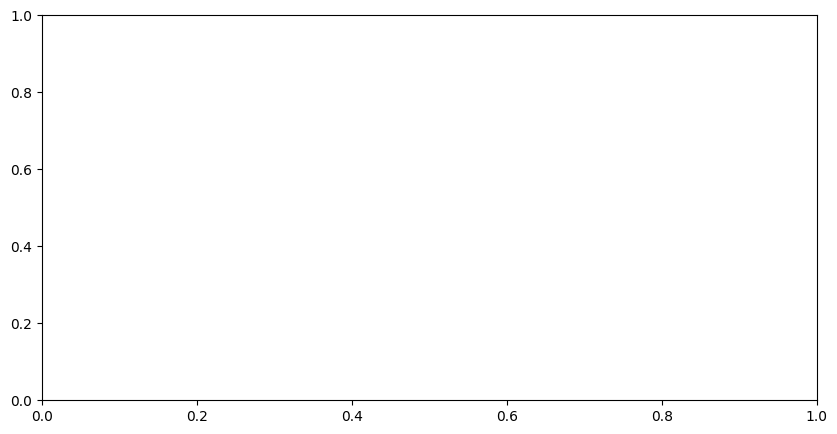

In [ ]:
# import gc
# import torch

# gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

lr = 1.0e-5

weight_decay = 1.0e-4

model = SimpleModel(
    num_historical_features=ticker_dataset_train.X.shape[2],
    encoder_length=window_size,
    hidden_size=2048,  # Réduit: 2048 → 512
    dropout=0.6,  # Augmenté: 0.3 → 0.5 pour éviter le surapprentissage
    lstm_layers=8,  # Réduit: 8 → 2
    n_heads=8,  # Réduit: 32 → 4
    num_attention_layers=8,  # Réduit: 16 → 2
    patch_size=int(window_size / 8),  # Plus de patches: /4 → /8
)

model_nb_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model_size_in_b = model_nb_params / 1e9

print(f"Model size: {model_nb_params} parameters")

print(f"Model size: {model_size_in_b:.3f}B parameters")


print(f"Ticker train X : {len(ticker_dataset_train.X)}")

print(f"Ticker train Y : {len(ticker_dataset_train.y_cls)}")

print(f"Ticker train Y : {len(ticker_dataset_train.y_ret)}")

print(f"Ticker train Y : {len(ticker_dataset_train.y_vol)}")

print(f"Ticker val X : {ticker_dataset_val.X.shape}")

print(f"Ticker val Y : {ticker_dataset_val.y_cls.shape}")

print(f"Ticker val Y : {ticker_dataset_val.y_ret.shape}")

print(f"Ticker val Y : {ticker_dataset_val.y_vol.shape}")


trainer = Trainer(
    ticker_dataset_train=ticker_dataset_train,
    ticker_dataset_val=ticker_dataset_val,
    model=model,
    batch_size=batch_size,
    lr=lr,
    weight_decay=weight_decay,
    windows_size=window_size,
)

trainer.train()
